In [1]:
# 📌 Import necessary libraries for data handling, visualization, and modeling
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from google.colab import files
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
path="/content/drive/MyDrive/DA FG/"

In [5]:
print (path)

/content/drive/MyDrive/DA FG/


In [6]:
df = pd.read_csv(path+'mymoviedb (1).csv', engine='python', on_bad_lines='warn')

In [7]:
df.head()

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,2021-12-15,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,2022-03-01,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,2022-02-25,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,2021-11-24,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4,2021-12-22,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7.0,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...


In [ ]:
df.shape

(9837, 9)

In [ ]:
df.columns

Index(['Release_Date', 'Title', 'Overview', 'Popularity', 'Vote_Count',
       'Vote_Average', 'Original_Language', 'Genre', 'Poster_Url'],
      dtype='object')

In [ ]:
df.dtypes

,0
Release_Date,object
Title,object
Overview,object
Popularity,float64
Vote_Count,object
Vote_Average,object
Original_Language,object
Genre,object
Poster_Url,object


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9837 entries, 0 to 9836
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Release_Date       9837 non-null   object 
 1   Title              9828 non-null   object 
 2   Overview           9828 non-null   object 
 3   Popularity         9827 non-null   float64
 4   Vote_Count         9827 non-null   object 
 5   Vote_Average       9827 non-null   object 
 6   Original_Language  9827 non-null   object 
 7   Genre              9826 non-null   object 
 8   Poster_Url         9826 non-null   object 
dtypes: float64(1), object(8)
memory usage: 691.8+ KB


In [ ]:
df.isnull().sum()

,0
Release_Date,0
Title,9
Overview,9
Popularity,10
Vote_Count,10
Vote_Average,10
Original_Language,10
Genre,11
Poster_Url,11


In [ ]:
# Drop columns not needed for analysis
df.drop(columns=['Poster_Url', 'Overview'], inplace=True)

In [ ]:
df.isnull().sum().sum()

np.int64(60)

In [ ]:
df = df.dropna()

In [ ]:
df.isnull().sum()

,0
Release_Date,0
Title,0
Overview,0
Popularity,0
Vote_Count,0
Vote_Average,0
Original_Language,0
Genre,0
Poster_Url,0


In [ ]:
df['Title'] = df['Title'].str.replace('"', '', regex=False).str.strip()
df['Genre'] = df['Genre'].str.replace('"', '', regex=False).str.strip()

df.fillna('', inplace=True)
import csv
df.to_csv('movies_analysis.csv', index=False, quoting=csv.QUOTE_NONNUMERIC)

In [ ]:
df.shape

(9826, 7)

In [ ]:
df.to_csv('netflix_cleaned.csv', index=False)

In [ ]:
from google.colab import files
files.download('netflix_cleaned.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

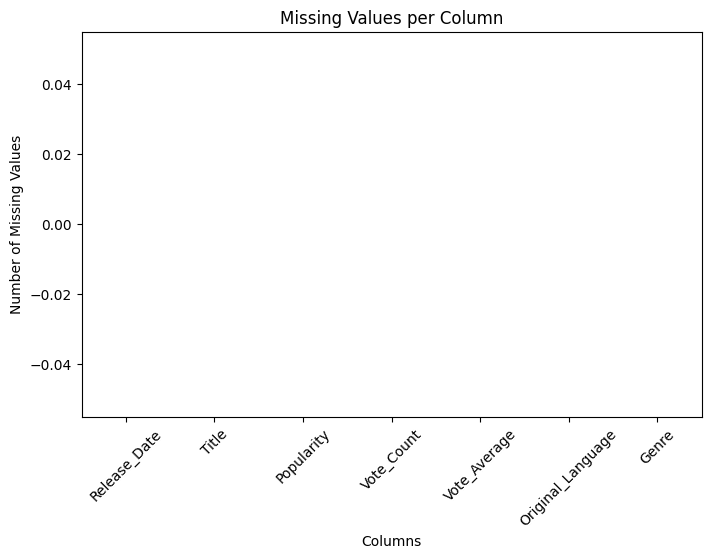

In [ ]:
missing = df.isnull().sum()

plt.figure(figsize=(8,5))
missing.plot(kind='bar')
plt.title('Missing Values per Column')
plt.xlabel('Columns')
plt.ylabel('Number of Missing Values')
plt.xticks(rotation=45)
plt.show()

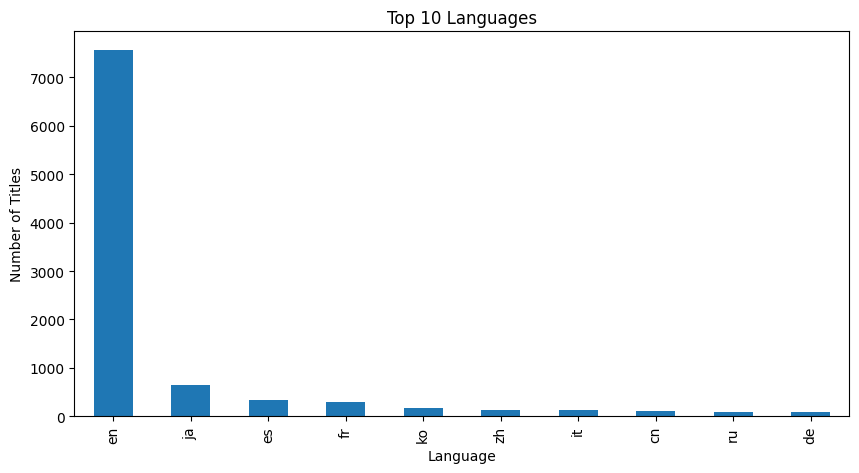

In [8]:
df['Original_Language'].value_counts().head(10).plot(
    kind='bar',
    figsize=(10,5)
)

plt.title('Top 10 Languages')
plt.xlabel('Language')
plt.ylabel('Number of Titles')
plt.show()

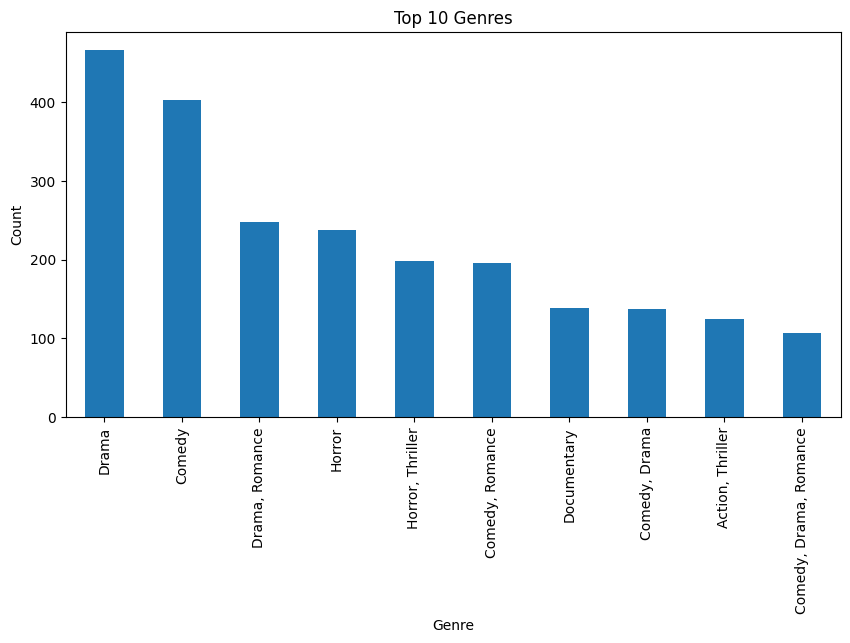

In [9]:
top_genres = df['Genre'].value_counts().head(10)

top_genres.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title('Top 10 Genres')
plt.xlabel('Genre')
plt.ylabel('Count')
plt.show()

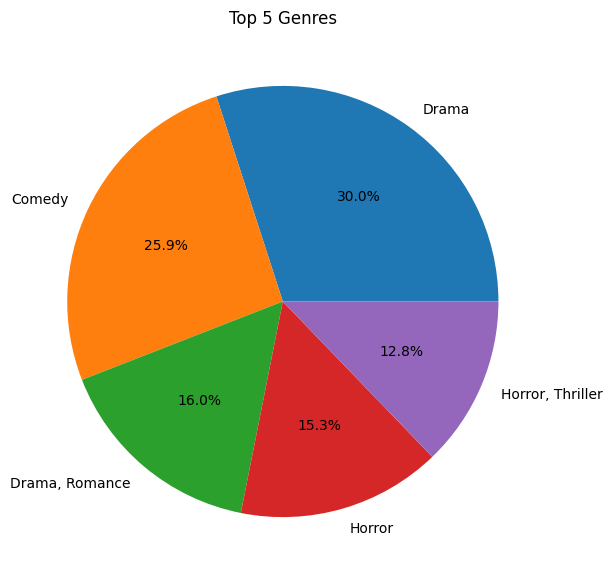

In [14]:
#piechart
top_genres = df['Genre'].value_counts().head(5)

plt.figure(figsize=(7,7))
plt.pie(
    top_genres,
    labels=top_genres.index,
    autopct='%1.1f%%'
)

plt.title('Top 5 Genres')
plt.show()

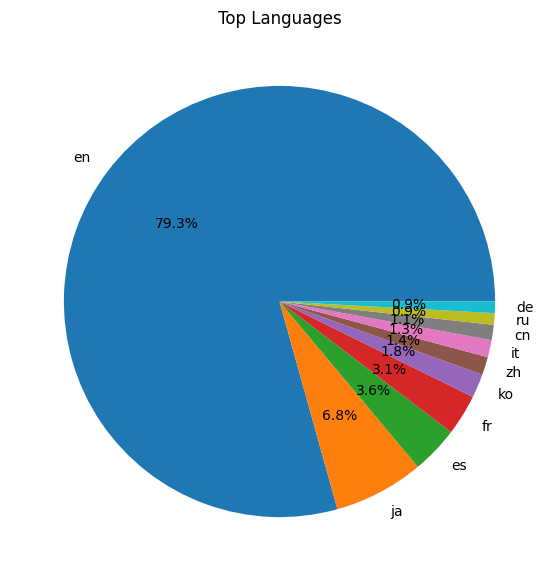

In [13]:
#Piechart
top_languages = df['Original_Language'].value_counts().head(10)

plt.figure(figsize=(7,7))
plt.pie(
    top_languages,
    labels=top_languages.index,
    autopct='%1.1f%%'
)

plt.title('Top Languages')
plt.show()

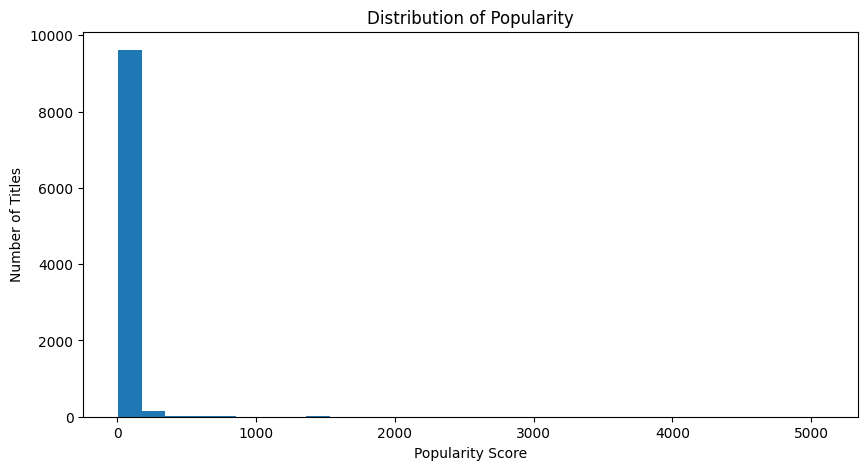

In [15]:
#histogram
plt.figure(figsize=(10,5))

plt.hist(df['Popularity'], bins=30)

plt.title('Distribution of Popularity')
plt.xlabel('Popularity Score')
plt.ylabel('Number of Titles')

plt.show()

In [17]:
top_popular = df.sort_values(
    by='Popularity',
    ascending=False
)

top20 = top_popular[['Title','Popularity']].head(20)

top20

,Title,Popularity
0,Spider-Man: No Way Home,5083.954
1,The Batman,3827.658
2,No Exit,2618.087
3,Encanto,2402.201
4,The King's Man,1895.511
5,The Commando,1750.484
6,Scream,1675.161
7,Kimi,1601.782
8,Fistful of Vengeance,1594.013
9,Eternals,1537.406


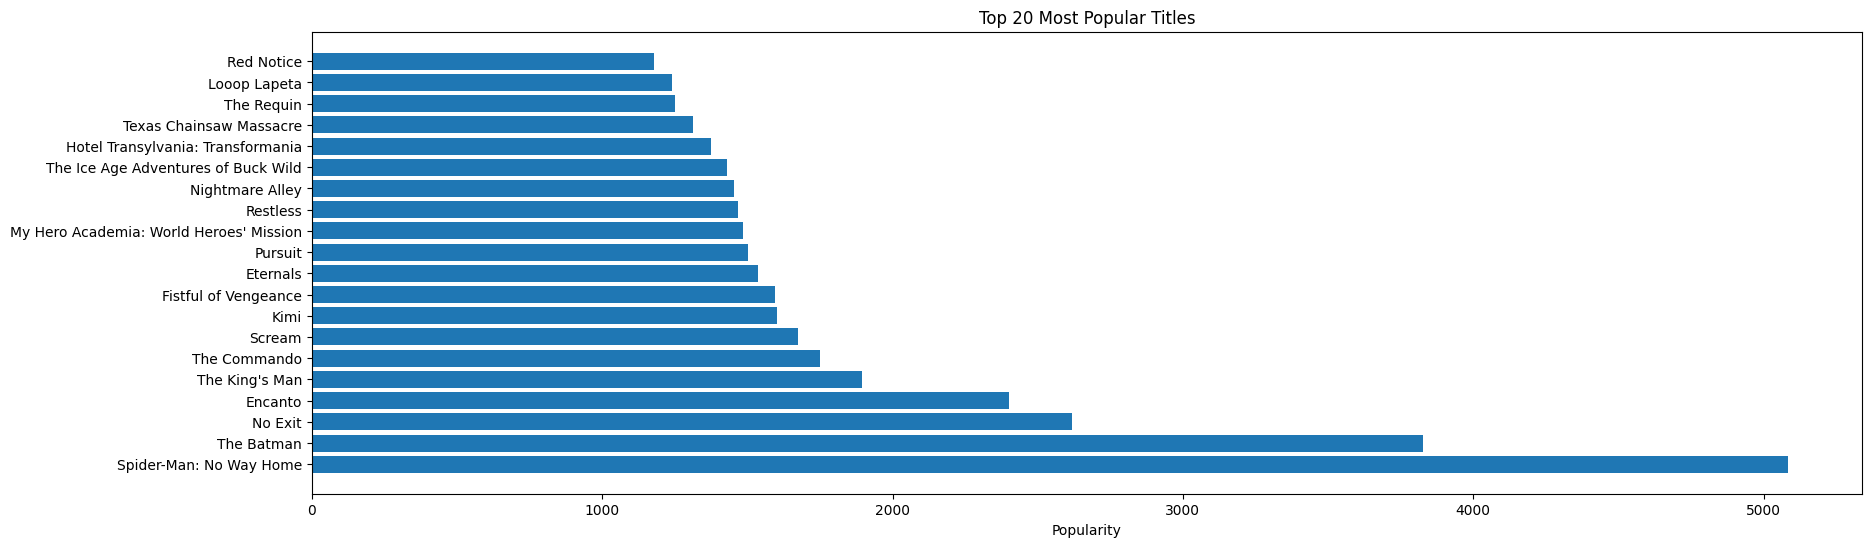

In [19]:
plt.figure(figsize=(20,6))

plt.barh(
    top20['Title'],
    top20['Popularity']
)

plt.title('Top 20 Most Popular Titles')
plt.xlabel('Popularity')

plt.show()

In [ ]:
#language count
language_counts = df['Original_Language'].value_counts()

print(language_counts.head(20))

Original_Language
en    7569
ja     645
es     339
fr     292
ko     170
zh     129
it     123
cn     109
ru      83
de      82
pt      37
da      28
no      26
hi      26
sv      23
nl      21
th      17
pl      17
tr      15
id      15
Name: count, dtype: int64


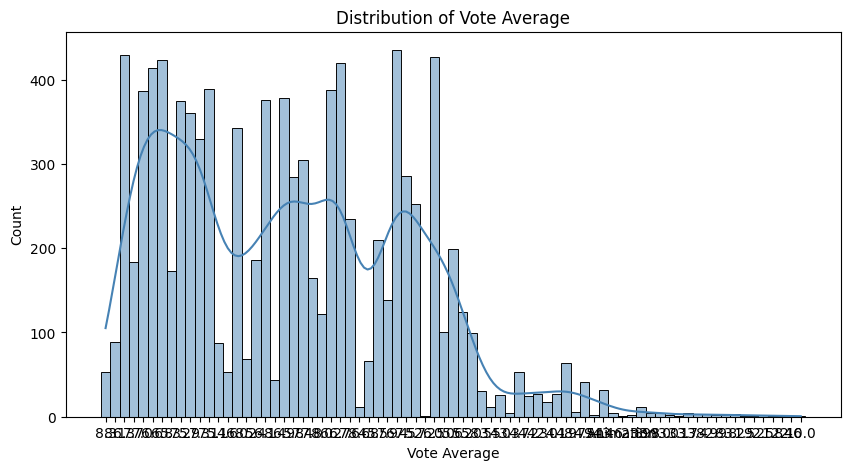

In [20]:
plt.figure(figsize=(10,5))
sns.histplot(df['Vote_Average'], bins=20, kde=True, color='steelblue')
plt.title('Distribution of Vote Average')
plt.xlabel('Vote Average')
plt.ylabel('Count')
plt.show()

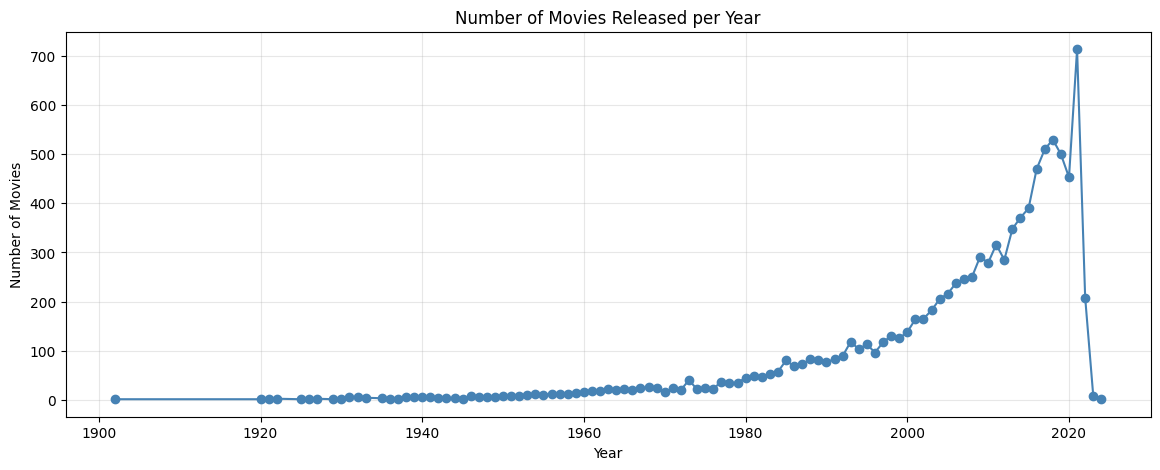

In [24]:
df['Release_Date'] = pd.to_datetime(df['Release_Date'], errors='coerce')
df['Year'] = df['Release_Date'].dt.year

movies_per_year = df['Year'].value_counts().sort_index()

plt.figure(figsize=(14,5))
plt.plot(movies_per_year.index, movies_per_year.values, marker='o', linewidth=1.5, color='steelblue')
plt.title('Number of Movies Released per Year')
plt.xlabel('Year')
plt.ylabel('Number of Movies')
plt.grid(True, alpha=0.3)
plt.show()

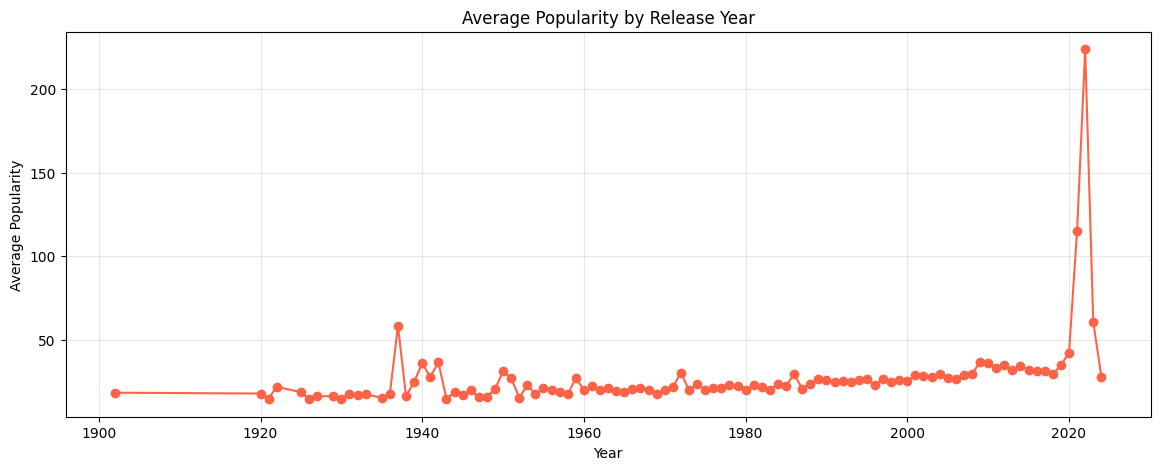

In [25]:
avg_popularity_year = df.groupby('Year')['Popularity'].mean().dropna()

plt.figure(figsize=(14,5))
plt.plot(avg_popularity_year.index, avg_popularity_year.values, marker='o', linewidth=1.5, color='tomato')
plt.title('Average Popularity by Release Year')
plt.xlabel('Year')
plt.ylabel('Average Popularity')
plt.grid(True, alpha=0.3)
plt.show()

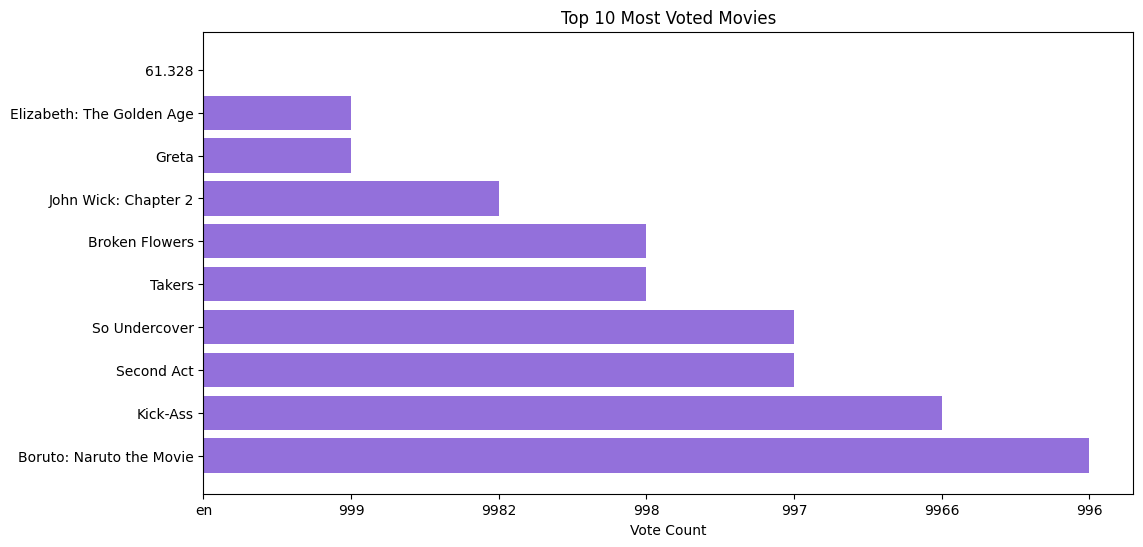

In [27]:
top_voted = df.sort_values(by='Vote_Count', ascending=False).head(10)

plt.figure(figsize=(12,6))
plt.barh(top_voted['Title'], top_voted['Vote_Count'], color='mediumpurple')
plt.title('Top 10 Most Voted Movies')
plt.xlabel('Vote Count')
plt.gca().invert_yaxis()
plt.show()

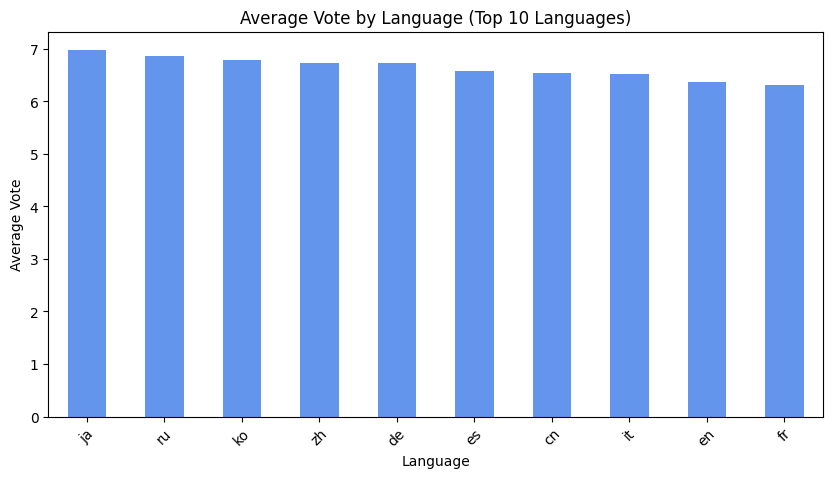

In [33]:
top_langs = df['Original_Language'].value_counts().head(10).index
df['Vote_Average'] = pd.to_numeric(df['Vote_Average'], errors='coerce')

lang_vote = df[df['Original_Language'].isin(top_langs)].groupby('Original_Language')['Vote_Average'].mean().sort_values(ascending=False)

plt.figure(figsize=(10,5))
lang_vote.plot(kind='bar', color='cornflowerblue')
plt.title('Average Vote by Language (Top 10 Languages)')
plt.xlabel('Language')
plt.ylabel('Average Vote')
plt.xticks(rotation=45)
plt.show()

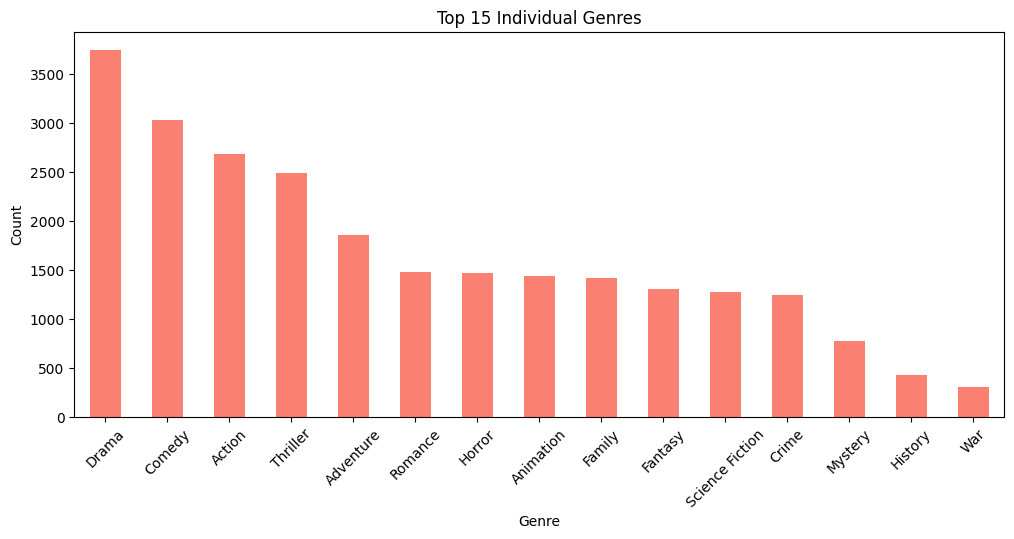

In [30]:
genre_exploded = df['Genre'].dropna().str.split(',').explode().str.strip()
genre_counts = genre_exploded.value_counts().head(15)

plt.figure(figsize=(12,5))
genre_counts.plot(kind='bar', color='salmon')
plt.title('Top 15 Individual Genres')
plt.xlabel('Genre')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

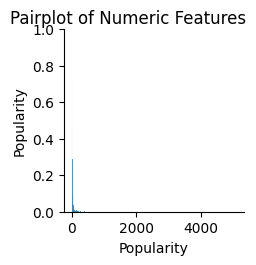

In [31]:
sns.pairplot(df[['Popularity', 'Vote_Count', 'Vote_Average']].dropna())
plt.suptitle('Pairplot of Numeric Features', y=1.02)
plt.show()